# 0. Imports and Initial Configs

## 0.1 - Imports

In [1]:
# General Libs
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt

# Configs libs
import ipytest
import warnings
from IPython.display import display

# Others
from statsmodels.tsa.seasonal import seasonal_decompose

## 0.2 - Initial Config

In [2]:
# Comando para remover os warnings
warnings.filterwarnings("ignore")

# Comando para configurar o pandas e remover o limite de exibição
# de linhas e colunas
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', None)

# Comando para configurar a lib `ipytest` e possibilitar a criação
# de testes unitários no notebook
ipytest.autoconfig()

# Adjust Figure size
sns.set_theme(rc={'figure.figsize':(12,8)})

# Suppres scientific notation
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

## 0.3 - Load Data

In [3]:
df_raw = pd.read_csv("/home/ubuntu/dev/projects/tcc/tcc_mba/hydrometeorological-anomalies-prophet/dados/processed/serie_prophet_rmr_2020_2025.csv")

In [4]:
df_raw.head(3).T

,0,1,2
ds,2020-01-01,2020-01-02,2020-01-03
y,20.482,16.079,24.879


In [5]:
df_raw.shape

(2192, 2)

# 1. Pre Processing

In [6]:
df1 = df_raw.copy()

df1.shape

(2192, 2)

## 1.1 - Data Types

In [7]:
df1.dtypes

ds        str
y     float64
dtype: object

## 1.2 - Check NA

In [8]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 2192 entries, 0 to 2191
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ds      2192 non-null   str    
 1   y       2192 non-null   float64
dtypes: float64(1), str(1)
memory usage: 34.4 KB


In [9]:
total_nulls = df1.isna().sum().sum()
total_elements = df1.size
percentage_nulls = (total_nulls / total_elements) * 100

print(f'Porcentagem total de dados nulos: {percentage_nulls:.2f}%')

Porcentagem total de dados nulos: 0.00%


In [10]:
round(df1.isna().sum() / df1.shape[0]*100,3)

ds   0.000
y    0.000
dtype: float64

## 1.3 - Check Duplicates

In [11]:
print(f"Datas duplicadas: {df1['ds'].duplicated().sum()}")

Datas duplicadas: 0


## 1.4 - Check daily data

In [12]:
df1['ds'] = pd.to_datetime(df1['ds'])

In [13]:
date_range = pd.date_range(start=df1['ds'].min(), end=df1['ds'].max(), freq='D')
missing_dates = set(date_range) - set(df1['ds'])
print(f"Datas faltantes: {len(missing_dates)}")

Datas faltantes: 0


# 2. Descriptive Statistics

In [14]:
df2 = df1.copy()

df2.shape

(2192, 2)

In [15]:
# Garantir que a coluna 'ds' está em datetime
df2['ds'] = pd.to_datetime(df2['ds'])

# Criar coluna de ano-mês
df2['ano_mes'] = df2['ds'].dt.strftime('%Y-%m')

# Calcular a média mensal (usando o próprio df2 diário)
media_mensal = df2.groupby('ano_mes')['y'].mean().rename('media_mensal')

# Mesclar de volta ao df2
df2 = df2.join(media_mensal, on='ano_mes')

df2.head(3)

,ds,y,ano_mes,media_mensal
0,2020-01-01,20.482,2020-01,17.375
1,2020-01-02,16.079,2020-01,17.375
2,2020-01-03,24.879,2020-01,17.375


In [16]:
# Estatísticas gerais
print(df2['y'].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

count   2,192.000
mean       40.651
std        64.144
min         0.038
10%         5.354
25%        12.755
50%        27.071
75%        46.483
90%        81.947
95%       122.179
99%       241.207
max     1,381.222
Name: y, dtype: float64


In [17]:
# Estatísticas por ano
df2['ano'] = df2['ds'].dt.year
print(df2.groupby('ano')['y'].agg(['mean', 'std', 'max', 'sum']))

       mean    std       max        sum
ano                                    
2020 37.315 51.109   529.396 13,657.424
2021 35.900 34.293   338.699 13,103.378
2022 51.657 96.430 1,228.613 18,854.806
2023 38.790 42.716   356.585 14,158.195
2024 39.833 84.633 1,381.222 14,578.940
2025 40.423 50.050   467.640 14,754.467


In [18]:
# Estatísticas por mês (padrão sazonal)
df2['mes'] = df2['ds'].dt.month
mes_stats = df2.groupby('mes')['y'].agg(['mean', 'std', 'max', 'count'])
print(mes_stats)

      mean     std       max  count
mes                                
1   29.940  35.259   328.658    186
2   43.216 107.069 1,381.222    170
3   50.381  52.924   429.202    186
4   40.777  36.847   263.767    180
5   69.084 120.832 1,228.613    186
6   76.147  87.528   731.066    180
7   49.953  56.319   547.503    186
8   41.686  50.412   467.640    186
9   25.422  20.520    95.981    180
10  18.928  14.623    86.126    186
11  18.654  18.430   159.340    180
12  23.793  20.544   159.491    186


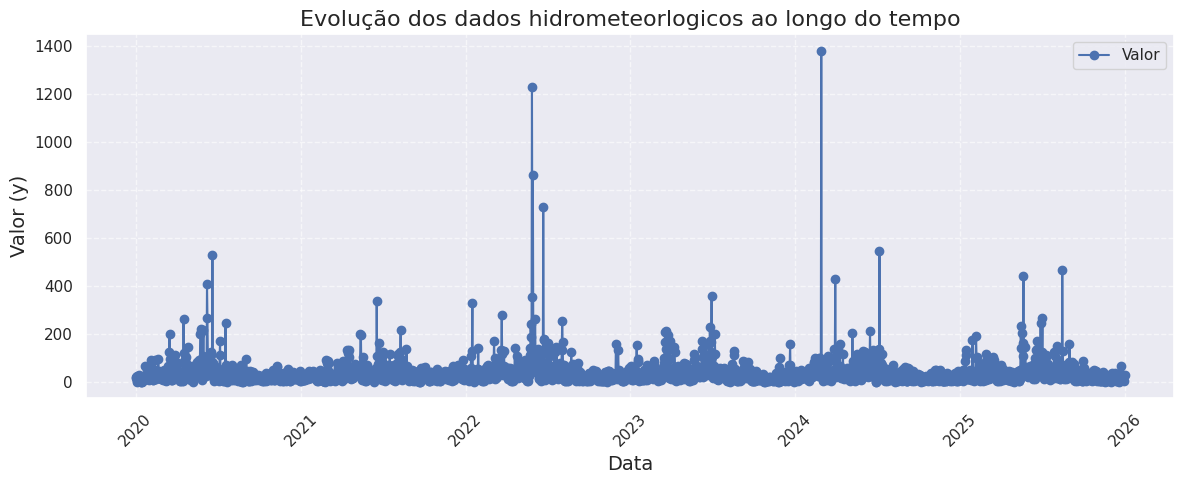

In [19]:
plt.figure(figsize=(12, 5))
plt.plot(df2['ds'], df2['y'], marker='o', linestyle='-', color='b', label='Valor')
plt.title('Evolução dos dados hidrometeorlogicos ao longo do tempo', fontsize=16)
plt.xlabel("Data", fontsize=14)
plt.ylabel("Valor (y)", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

**Análise Descritiva e Exploratória dos Dados**

**1. Caracterização da Distribuição: Assimetria e Comportamento Extremo**

A análise dos dados revela inicialmente uma discrepância relevante entre a média (40,65) e a mediana (27,07). Essa diferença indica a presença de assimetria positiva (à direita) na distribuição, sugerindo que a maioria das observações concentra-se em valores baixos, enquanto uma parcela reduzida de dias registra valores expressivamente elevados, os quais elevam a média aritmética.

O desvio-padrão (64,14) supera o valor da própria média, evidenciando elevada dispersão e volatilidade dos dados. Ademais, observa-se que 99% das observações situam-se abaixo de 241,2, ao passo que o valor máximo atinge 1.381,2. Esse máximo é aproximadamente seis vezes superior ao limite do percentil 99, configurando a ocorrência de eventos extremos (outliers), possivelmente associados a fenômenos como tempestades intensas ou episódios de cheia.

**2. Padrão Sazonal: Variação Mensal**

A agregação dos dados por mês permite identificar um ciclo anual bem definido:

- **Período de maior magnitude**: Os meses de maio (média = 69,08) e junho (média = 76,14) apresentam as maiores médias mensais. Junho destaca-se também pelo elevado desvio-padrão, indicando que, embora consistentemente volumoso, exibe considerável variabilidade intra-mensal.
- **Período de estiagem**: Outubro (média = 18,92) e novembro (média = 18,65) registram os menores valores médios, caracterizando a estação seca ou de baixa atividade.
- **Comportamento atípico em fevereiro**: Embora sua média (43,21) seja moderada, fevereiro apresenta o valor máximo absoluto da série (1.381,2). Esse achado sugere a ocorrência de um evento pontual de curta duração e altíssima intensidade, destoando do padrão geral do mês.

**3. Análise Interanual**

A comparação entre os anos revela diferenças significativas:

- Os anos de 2022 e 2024 destacam-se como atípicos. 2022 registrou a maior média anual (51,65), enquanto 2024 apresentou o pico máximo absoluto da série.
- Em contraste, o ano de 2021 caracterizou-se por maior estabilidade e menores magnitudes, com a menor média anual (35,90) e o menor valor máximo entre todos os anos analisados.


# 3. Trend and Seasonality Analysis

In [20]:
df3 = df2.copy()

df3.shape

(2192, 6)

In [21]:
df3.head(2)

,ds,y,ano_mes,media_mensal,ano,mes
0,2020-01-01,20.482,2020-01,17.375,2020,1
1,2020-01-02,16.079,2020-01,17.375,2020,1


## 3.1 - Linear Trend

In [22]:
# Converter data para ordinal (dias desde o início)
df3['t'] = (df3['ds'] - df3['ds'].min()).dt.days
slope, intercept, r_value, p_value, std_err = stats.linregress(df3['t'], df3['y'])
print(f"Tendência: {slope:.4f} mm/dia por dia (p={p_value:.4f})")

Tendência: -0.0010 mm/dia por dia (p=0.6339)


## 3.2 - Seasonal Decompose

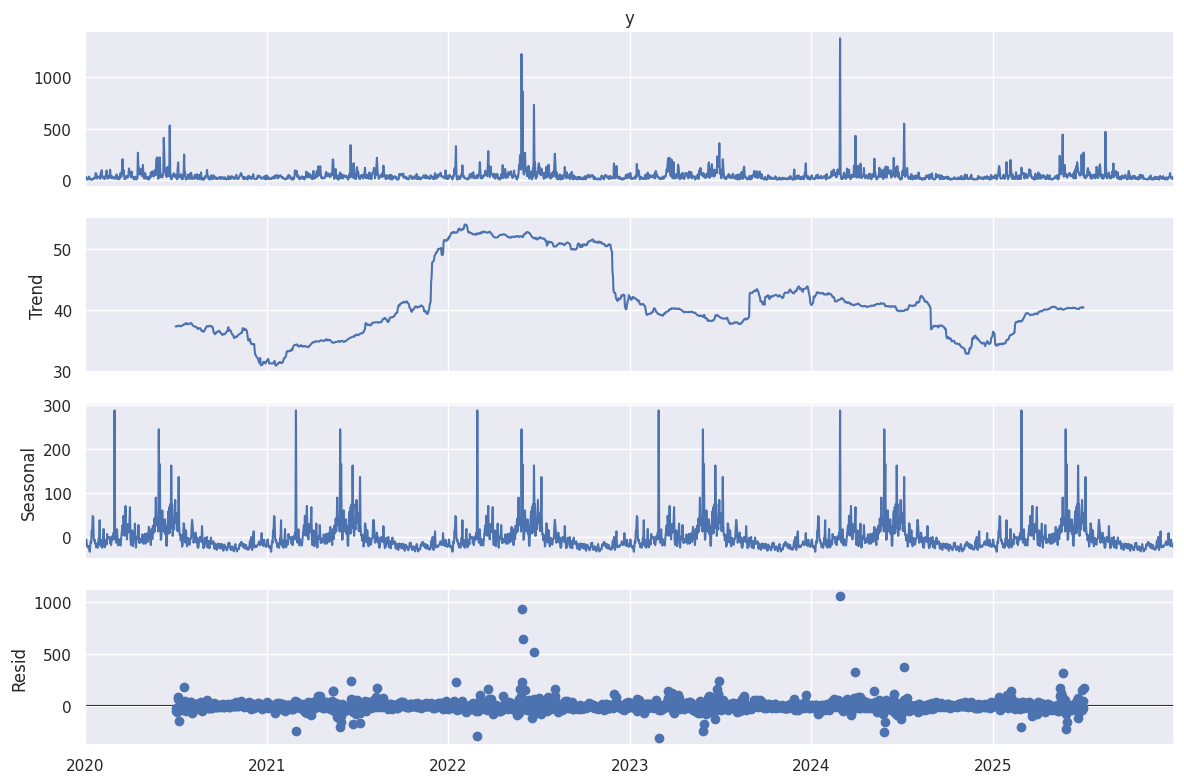

In [23]:
# Série diária – frequência 365 (ou 365.25)
decomp = seasonal_decompose(df3.set_index('ds')['y'], model='additive', period=365)
decomp.plot()
plt.show()

### 1. Análise da Tendência Linear via Regressão

Os resultados da regressão linear, embora aparentemente modestos, são estatisticamente informativos:

- **Significância estatística:** O valor-p associado ao coeficiente angular é 0,6339, muito superior ao limiar convencional de 0,05. Isso implica a inexistência de evidências estatísticas para rejeitar a hipótese nula de inclinação nula. Em outras palavras, **não se detecta uma tendência monotônica de longo prazo** (crescimento ou decrescimento) na série temporal analisada.
- **Magnitude da inclinação:** O coeficiente angular estimado é de -0,0010, valor praticamente indistinguível de zero em termos práticos.
- **Conclusão preliminar:** O processo hidrometeorológico subjacente comporta-se como estacionário em média no período investigado, ou seja, não há evidências de um padrão linear de “secamento” ou “intensificação” ao longo dos anos.

### 2. Decomposição Aditiva da Série Temporal

A análise do gráfico de decomposição aditiva (tendência + sazonalidade + resíduos) revela aspectos complementares importantes:

- **Componente de tendência local (Trend):** Diferentemente do modelo linear global, a tendência local (obtida por média móvel) evidencia uma elevação perceptível por volta de **2022**, atingindo valores próximos a 55. Esse achado corrobora a média anual mais elevada identificada na análise descritiva anterior. Posteriormente, a tendência retorna a patamares em torno de 40.
- **Componente sazonal (Seasonal):** O gráfico confirma um padrão cíclico anual bem definido. Ao especificar o período como 365 dias, o modelo isola a variação que se repete a cada ano. Cabe notar que as amplitudes da componente sazonal são inferiores aos picos absolutos da série, indicando que a sazonalidade explica a variabilidade de “fundo”, mas não captura adequadamente os eventos extremos.
- **Componente residual (Resid / Irregularidade):** Este é o aspecto mais crítico da análise. Os resíduos ainda exibem picos de grande magnitude (superiores a 1000). **Interpretação:** O modelo aditivo (tendência + sazonalidade) é insuficiente para explicar a ocorrência de eventos extremos. Na hidrologia, essa característica é comum: grandes cheias ou tempestades constituem componentes estocásticas (aleatórias) que não seguem o calendário sazonal médio, demandando modelos complementares (ex.: distribuição de valores extremos, modelos de cauda pesada).

# 4. Outliers

In [24]:
df4 = df3.copy()

df4.shape

(2192, 7)

In [25]:
Q1 = df4['y'].quantile(0.25)
Q3 = df4['y'].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR
outliers_iqr = df4[df4['y'] > limite_superior]
print(f"Outliers (IQR): {len(outliers_iqr)} dias")

Outliers (IQR): 173 dias


In [26]:
z_scores = np.abs(stats.zscore(df4['y']))
outliers_z = df4[z_scores > 3]  # 3 desvios padrão
outliers_z

,ds,y,ano_mes,media_mensal,ano,mes,t
106,2020-04-16,263.767,2020-04,52.617,2020,4,106
158,2020-06-07,409.417,2020-06,87.939,2020,6,158
159,2020-06-08,266.065,2020-06,87.939,2020,6,159
170,2020-06-19,529.396,2020-06,87.939,2020,6,170
199,2020-07-18,245.561,2020-07,42.266,2020,7,199
534,2021-06-18,338.699,2021-06,51.454,2021,6,534
746,2022-01-16,328.658,2022-01,47.254,2022,1,746
811,2022-03-22,279.754,2022-03,66.567,2022,3,811
875,2022-05-25,240.979,2022-05,138.161,2022,5,875
878,2022-05-28,"1,228.613",2022-05,138.161,2022,5,878


In [27]:
# Usando os resíduos da decomposição
residuo = decomp.resid.dropna()
z_resid = np.abs(stats.zscore(residuo))
outliers_resid = residuo[z_resid > 3]
print(f"Outliers sazonais: {len(outliers_resid)} dias")

Outliers sazonais: 23 dias


In [29]:
limite_95 = df4['y'].quantile(0.95)
limite_99 = df4['y'].quantile(0.99)
dias_extremos = df4[df4['y'] > limite_99]
print(f"Dias com chuva > percentil 99: {len(dias_extremos)}")

Dias com chuva > percentil 99: 22


### 4. Detecção de Outliers: Discrepância entre Métodos e Implicações Estatísticas

#### 4.1. Comparação entre IQR e Z-Score

Observa-se uma divergência substancial entre os dois métodos empregados: o intervalo interquartil $IQR$ identificou **173 dias** como outliers, enquanto o escore Z (com limiar de 3 desvios-padrão) resultou em aproximadamente **24 ocorrências**.

Essa discrepância decorre da não normalidade da distribuição dos dados. A série apresenta acentuada assimetria positiva, violando o pressuposto de Gaussianidade subjacente ao método do escore Z. No caso do **IQR** ($Limite = Q_3 + 1,5 \times IQR$), o ponto de corte é relativamente baixo, capturando valores que podem ser considerados “altos” ou “fortes”, mas não necessariamente raros do ponto de vista probabilístico. Já o **escore Z**, definido como ($Z = \frac{x - \mu}{\sigma}$), tem seu limiar elevado artificialmente porque o desvio-padrão ($\sigma$) é inflacionado pela presença de picos extremos na série. Consequentemente, esse método só classifica como outliers os valores verdadeiramente excepcionais — os “eventos monstro”.

#### 4.2. Análise dos Outliers Sazonais (Resíduos da Decomposição)

O resultado mais relevante desta etapa é a identificação de **23 outliers sazonais** a partir da aplicação do escore Z sobre os resíduos da decomposição da série temporal. O procedimento adotado — subtrair da série original as componentes de tendência e sazonalidade — permite isolar a parcela irregular (estocástica) dos dados. Dessa forma, um valor elevado que ocorre, por exemplo, em junho (mês tipicamente úmido) é considerado normal pela componente sazonal; contudo, se esse mesmo valor persistir como outlier nos resíduos, ele evidencia um **evento extremo imprevisível**, independente do ciclo anual esperado.

É digno de nota que o número de outliers sazonais (23) é praticamente idêntico ao total de dias com valores acima do percentil 99 (22). Essa coincidência confirma que o “top 1%” da série é composto quase integralmente por anomalias puras, não explicáveis pelos padrões sazonais regulares.

#### 4.3. Identificação de Eventos Históricos

A tabela de escores Z revela assinaturas características de episódios climáticos específicos:

- **Evento persistente em maio de 2022:** Os índices 878, 879 e 880 correspondem a três dias consecutivos com valores extremamente elevados (1.228, 353 e 863, respectivamente). Essa sequência temporal contígua descarta a hipótese de erro isolado de medição e aponta para a atuação de um sistema climático de mesoescala ou grande escala, como uma Zona de Convergência do Atlântico Sul ou um sistema frontal estacionário.
- **Recorde absoluto em fevereiro de 2024:** O valor de 1.381 registrado em 28/02/2024 constitui um outlier tão extremo que, isoladamente, desloca a média anual de todo o ano de 2024, evidenciando o impacto desproporcional de eventos raros sobre estatísticas sumárias.

# 5. Indicadores de Risco de Imundação

In [30]:
df5 = df4.copy()

df5.shape

(2192, 7)

In [31]:
df5.head(3)

,ds,y,ano_mes,media_mensal,ano,mes,t
0,2020-01-01,20.482,2020-01,17.375,2020,1,0
1,2020-01-02,16.079,2020-01,17.375,2020,1,1
2,2020-01-03,24.879,2020-01,17.375,2020,1,2


## 5.1 - Dias consecutivos com chuva acima da média mensal

In [32]:
# Criar flag de excesso (diário > média mensal, já existente no seu notebook)
df5['acima_media'] = df5['y'] > df5['media_mensal']

# Identificar sequências
df5['sequencia'] = (df5['acima_media'] != df5['acima_media'].shift()).cumsum()
sequencias = df5[df5['acima_media']].groupby('sequencia').size()
print(f"Maior sequência de dias acima da média: {sequencias.max()} dias")

Maior sequência de dias acima da média: 14 dias


## 5.2 - Acumulado de chuva em janelas móveis (ex.: 5, 10, 30 dias)

In [33]:
for window in [5, 10, 30]:
    df5[f'acum_{window}d'] = df5['y'].rolling(window).sum()
    # Identificar janelas que ultrapassam um limiar crítico (ex.: 150 mm em 5 dias)
    limiar = 150 if window == 5 else (200 if window == 10 else 400)
    alertas = df5[df5[f'acum_{window}d'] > limiar]
    print(f"Janelas de {window} dias com acumulado > {limiar}mm: {len(alertas)} ocorrências")

Janelas de 5 dias com acumulado > 150mm: 1077 ocorrências
Janelas de 10 dias com acumulado > 200mm: 1679 ocorrências
Janelas de 30 dias com acumulado > 400mm: 2111 ocorrências


### 5. Análise de Persistência e Acumulados Temporais

#### 5.1. Persistência e Memória do Sistema

A identificação da maior sequência ininterrupta de **14 dias consecutivos** com valores acima da média mensal constitui um achado relevante para a compreensão da dinâmica hidrometeorológica local.

- **Saturação do solo:** Em sistemas hidrológicos, um período de 14 dias com precipitação ou vazão sistematicamente acima da média mensal sugere que o solo provavelmente atingiu sua capacidade máxima de retenção (condição de saturação). Esse estado modifica significativamente a resposta hidrológica a eventos subsequentes.
- **Escoamento superficial direto:** Uma vez saturado o solo, qualquer acréscimo pluviométrico, ainda que de intensidade modesta, converte-se predominantemente em escoamento superficial direto para os canais fluviais. Isso eleva substancialmente o risco de cheias rápidas (enxurradas) e de elevação repentina dos níveis d’água.

#### 5.2. Análise de Ocorrências por Janelas Móveis (Rolling Sum)

Os resultados obtidos para as janelas móveis de acumulação revelam números expressivos quando confrontados com a dimensão total da série (2.192 dias):

- **Janela de 5 dias (acumulado > 150 mm):** 1.077 ocorrências.
- **Janela de 30 dias (acumulado > 400 mm):** 2.111 ocorrências.

**Interpretação e implicações:**

1. **Calibração de limiares:** A ocorrência de 2.111 eventos em uma janela de 30 dias, sobre um total de 2.192 dias, implica que **praticamente qualquer período de 30 dias na série histórica ultrapassa o limiar de 400 mm**. Isso indica que o limiar adotado (400 mm/30 dias) pode estar subestimado para a realidade climática local, capturando não apenas eventos extremos, mas sim o comportamento climatológico de base. Recomenda-se, portanto, uma recalibração dos limiares com base em percentis superiores (ex.: percentil 90, 95 ou 99) para fins de alerta.

2. **Efeito de agrupamento (autocorrelação induzida pelo rolling):** O uso de janelas móveis gera dependência serial artificial: um único evento extremo de grande magnitude (ex.: 1.000 mm) contribuirá para o acúmulo de todas as janelas que o contiverem, produzindo “alertas” por até 30 dias consecutivos. Esse fenômeno deve ser considerado na análise de frequência, sob pena de superestimação da ocorrência independente de eventos críticos.

#### 5.3. Formulação Matemática da Soma Móvel

O procedimento adotado segue a definição clássica de soma móvel (rolling sum):

$\text{Accum}_{t, w} = \sum_{i=0}^{w-1} y_{t-i}$

em que $w$ representa o tamanho da janela (5, 10 ou 30 dias) e $y_{t-i}$ o valor observado no instante $t-i$. Cabe notar que, quanto maior o valor de $w$, mais suave se torna a curva acumulada, mas também mais prolongada é a duração do estado de “alerta” após um pico — uma consequência direta da memória da janela.

# 6. Graficos Gerais para  Padrões Temporais

In [34]:
df6 = df5.copy()

df6.shape

(2192, 12)

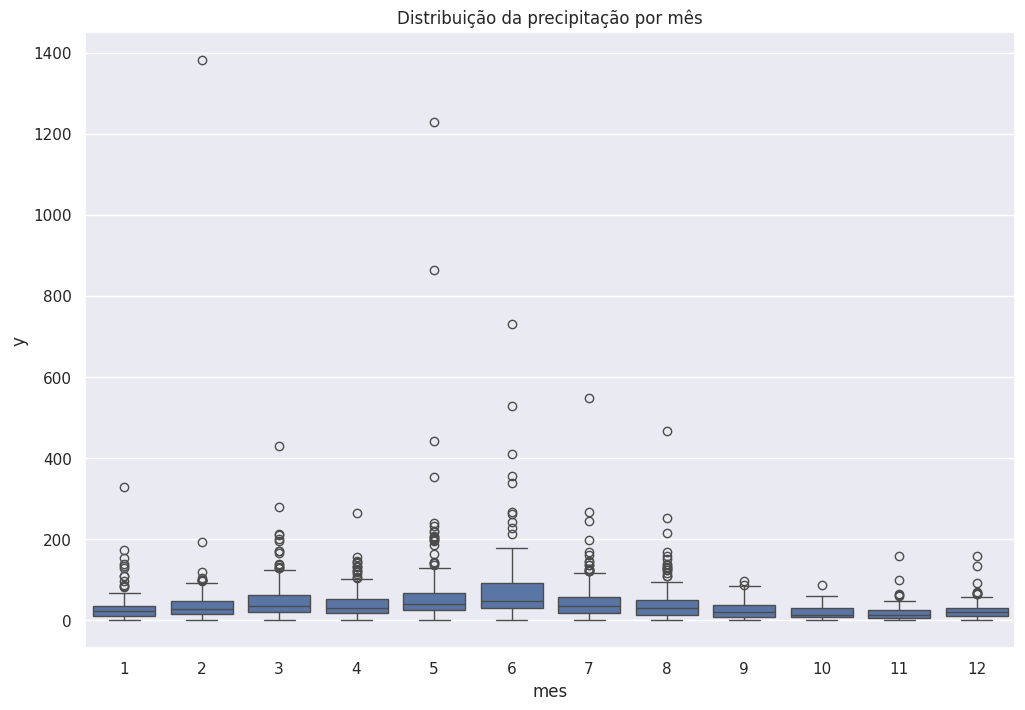

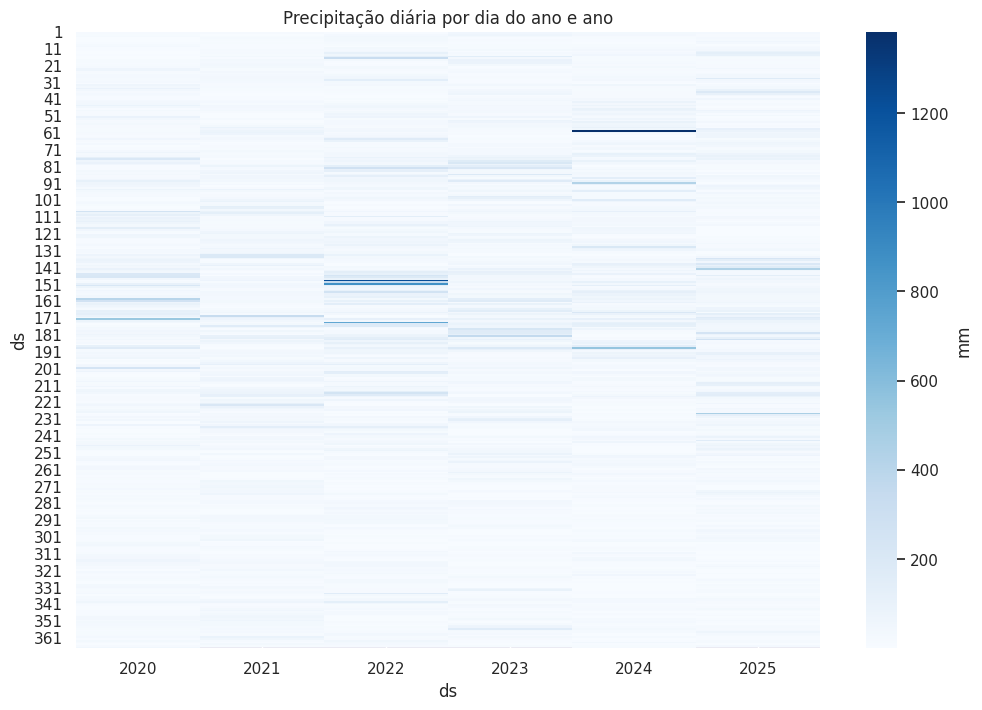

<Axes: title={'center': 'Chuva acumulada por ano'}, xlabel='ano'>

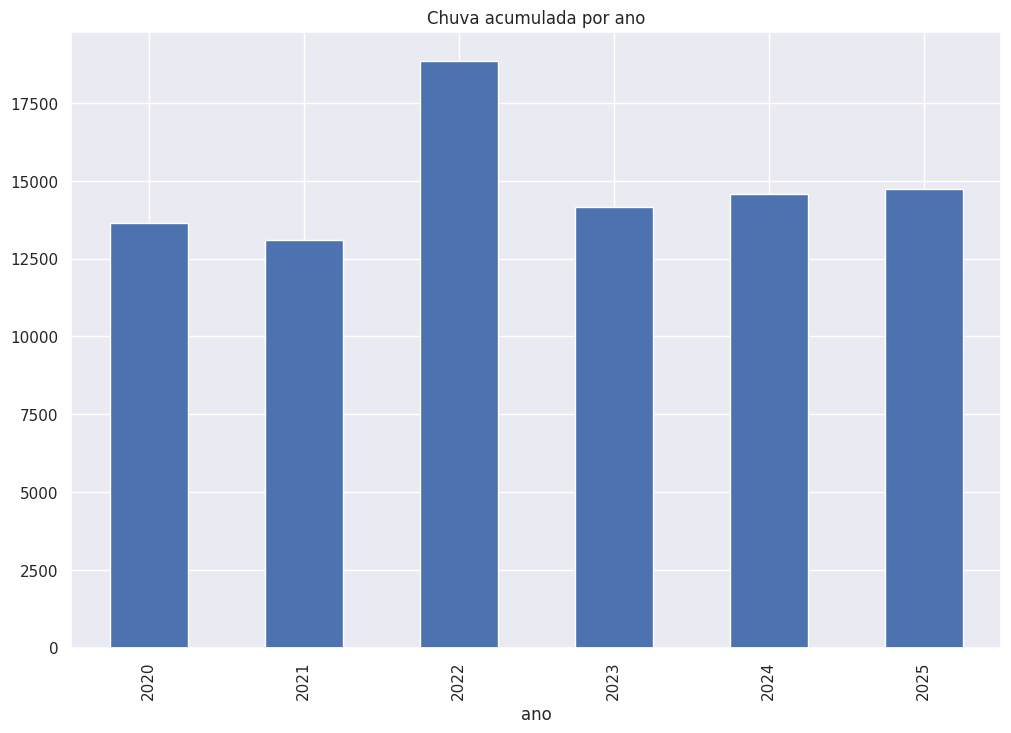

In [35]:
# Boxplot mensal
sns.boxplot(data=df6, x='mes', y='y')
plt.title('Distribuição da precipitação por mês')
plt.show()

# Heatmap (matriz dias x meses)
pivot = df6.pivot_table(index=df6['ds'].dt.dayofyear, columns=df6['ds'].dt.year, values='y')
sns.heatmap(pivot, cmap='Blues', cbar_kws={'label': 'mm'})
plt.title('Precipitação diária por dia do ano e ano')
plt.show()

# Acumulado anual
acum_ano = df6.groupby('ano')['y'].sum()
acum_ano.plot(kind='bar', title='Chuva acumulada por ano')

In [36]:
df_mensal = df5.groupby(['ano', 'mes'])['y'].mean().reset_index()

df_mensal['data'] = pd.to_datetime(
    df_mensal['ano'].astype(str) + '-' + 
    df_mensal['mes'].astype(str) + '-01'
)

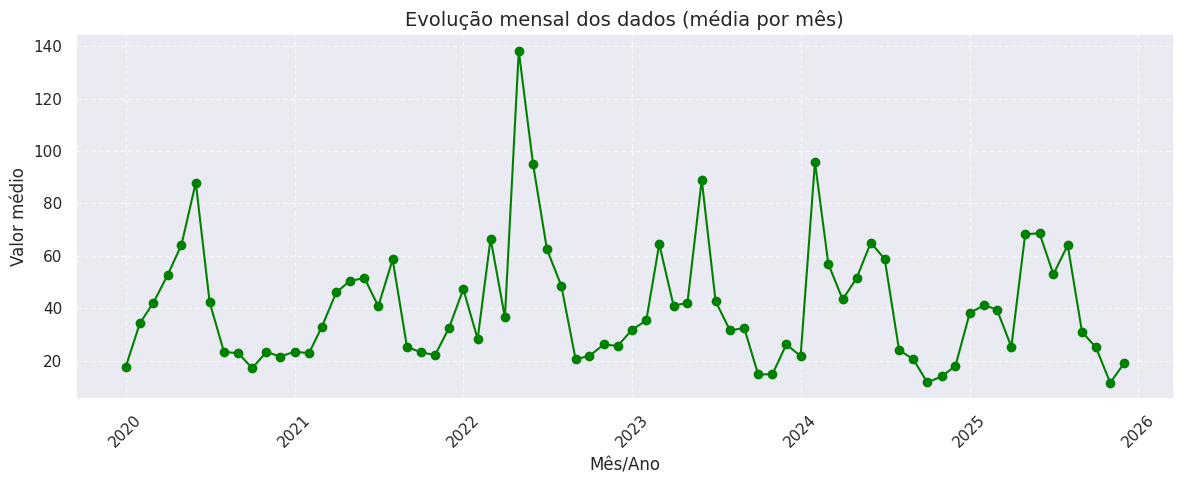

In [37]:
plt.figure(figsize=(12, 5))
plt.plot(df_mensal['data'], df_mensal['y'], marker='o', linestyle='-', color='green')
plt.title('Evolução mensal dos dados (média por mês)', fontsize=14)
plt.xlabel('Mês/Ano', fontsize=12)
plt.ylabel('Valor médio', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

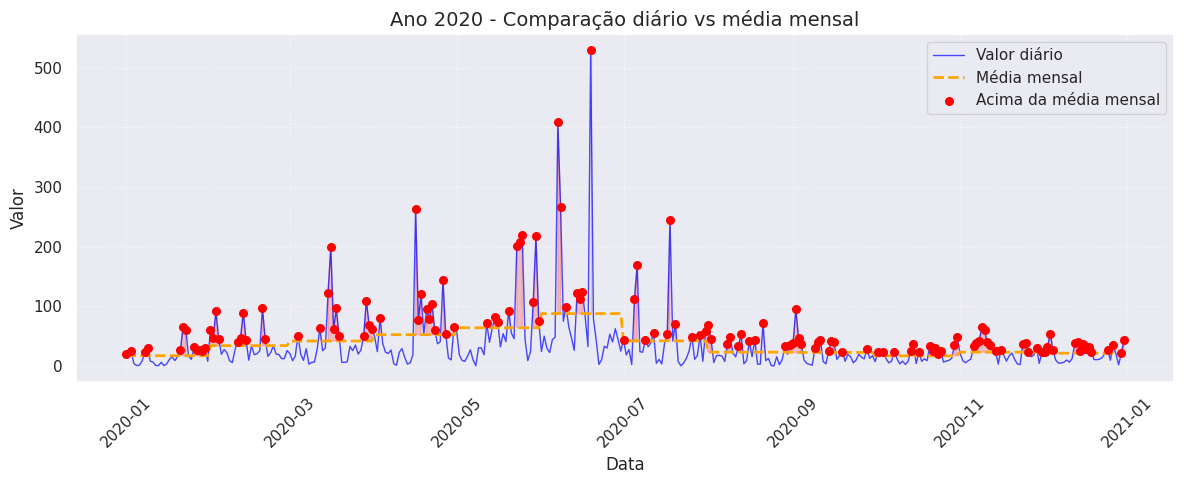

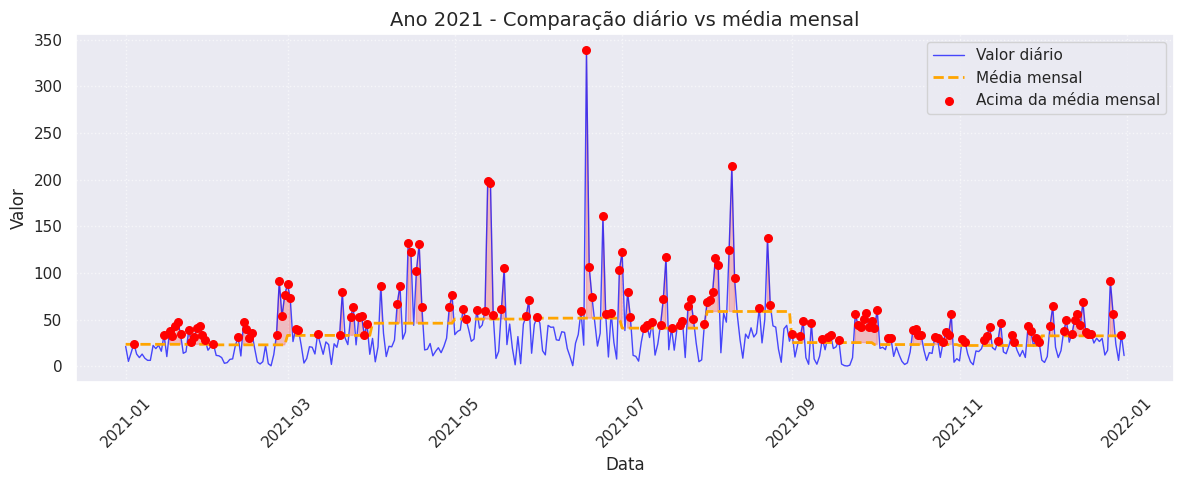

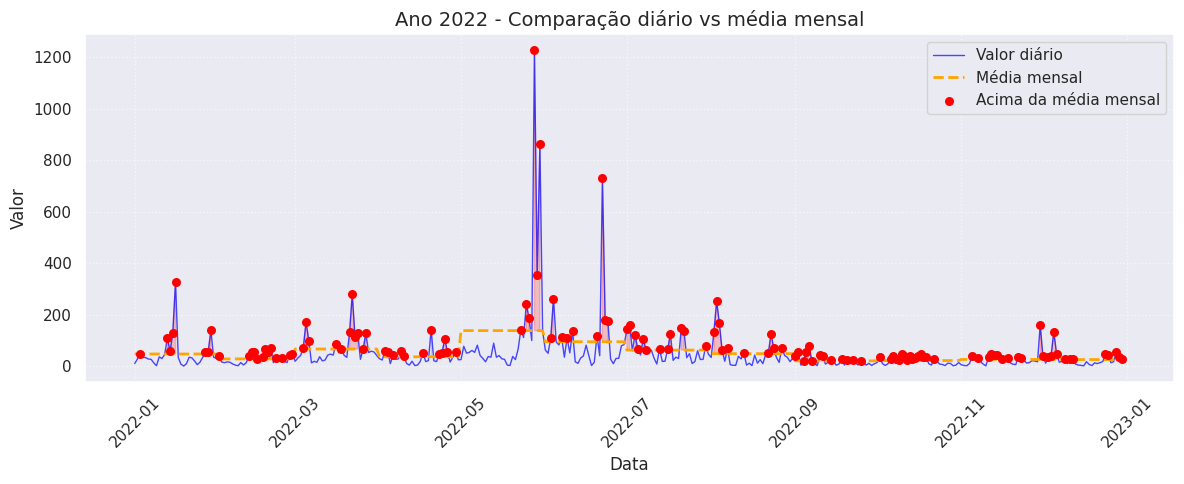

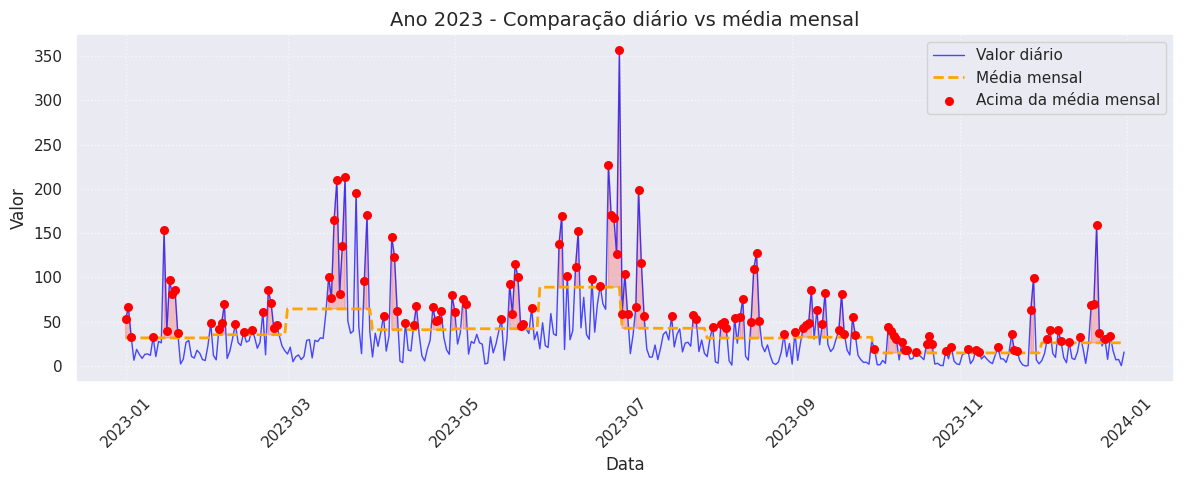

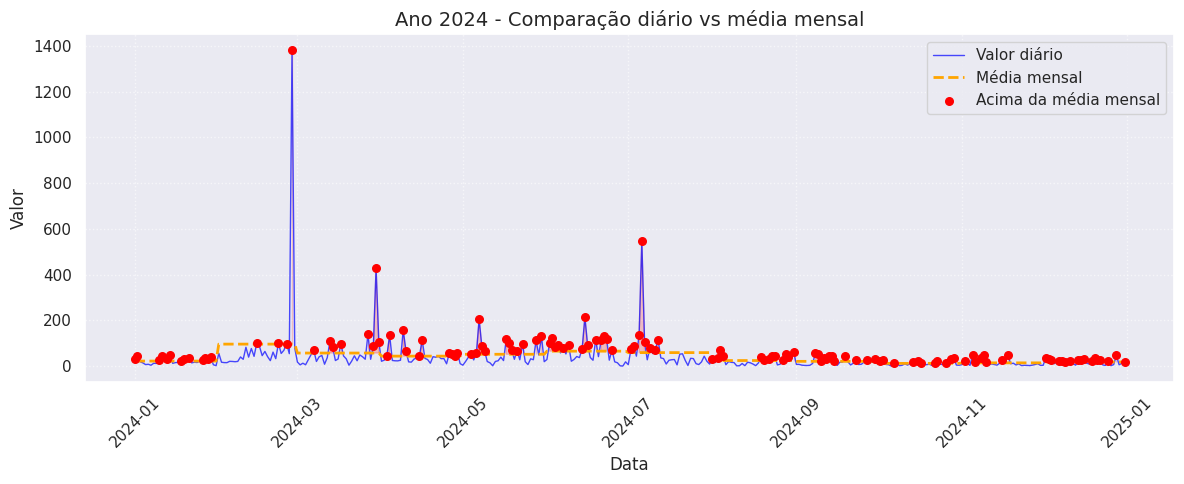

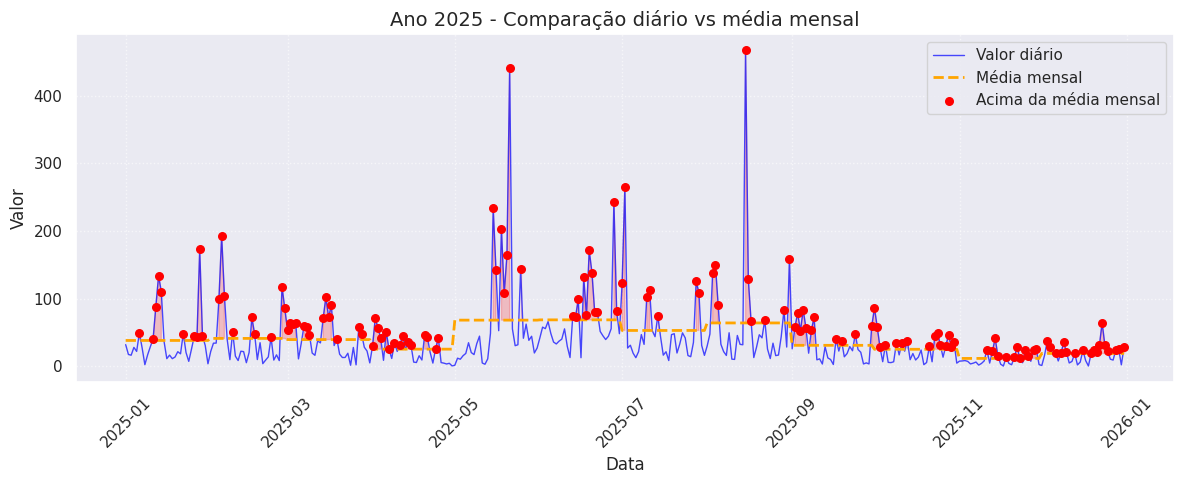

In [ ]:
#  Listar os anos presentes nos dados
anos = sorted(df5['ds'].dt.year.unique())

# Para cada ano, criar um gráfico separado
for ano in anos:
    # Filtrar dados do ano
    df_ano = df5[df5['ds'].dt.year == ano].copy()
    
    if df_ano.empty:
        continue
    
    # Criar figura e eixo
    plt.figure(figsize=(12, 5))
    
    # Linha diária
    plt.plot(df_ano['ds'], df_ano['y'], color='blue', linewidth=1, alpha=0.7, label='Valor diário')
    
    # Linha da média mensal (constante por mês)
    plt.plot(df_ano['ds'], df_ano['media_mensal'], color='orange', linewidth=2, linestyle='--', label='Média mensal')
    
    # Pontos onde diário > média mensal
    pontos = df_ano[df_ano['acima_media']]
    if not pontos.empty:
        plt.scatter(pontos['ds'], pontos['y'], color='red', s=30, zorder=5, label='Acima da média mensal')
    
    # Preenchimento opcional
    plt.fill_between(df_ano['ds'], df_ano['y'], df_ano['media_mensal'],
                     where=df_ano['y'] > df_ano['media_mensal'],
                     color='red', alpha=0.2)
    
    # Título e labels
    plt.title(f'Ano {ano} - Comparação diário vs média mensal', fontsize=14)
    plt.xlabel('Data', fontsize=12)
    plt.ylabel('Valor', fontsize=12)
    plt.legend(loc='best')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    # Mostrar (ou salvar) o gráfico
    plt.show()